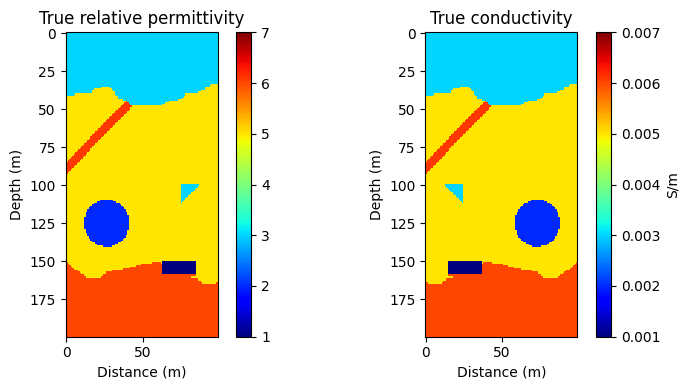

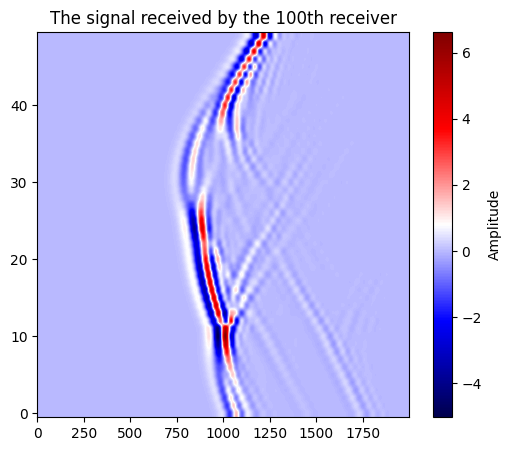

In [ ]:
import torch
import torch.nn.functional as F
import numpy as np
import sys 
from pathlib import Path
src_path=Path.cwd().parent / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))
import DeepGPR
import matplotlib.pyplot as plt
from skimage import filters
import time

# Set up the parameters and models
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
dx=0.05
dt=5e-11
nt=2000

source_location=torch.zeros((50,1,3),device=device,dtype=torch.int)
source_location[:,0,0]=torch.arange(10, 210, 4)
source_location[:,:,1]=10

receiver_location=torch.zeros((50,200,3),device=device,dtype=torch.int)
receiver_location[:,:,0]=torch.arange(10, 210, 1).repeat(50,1)
receiver_location[:,:,1]=110


freq=2e8
peak_time = 1 / freq
source_amplitudes = torch.zeros((1,nt,1),device=device)
source_amplitudes[0,:,0]=DeepGPR.ricker(freq, nt, dt, peak_time).to(device)


ert = F.pad(torch.tensor(np.load('2DFWImodel.npy')).unsqueeze(0).unsqueeze(0), pad=(10, 10, 10, 10), mode='replicate').squeeze()
set = ert.clone()*0.001
set[105:, :] = torch.flip(set[105:, :], dims=[1])

fig, axes = plt.subplots(1, 2, figsize=(8, 4))  
im1 = axes[0].imshow(ert[10:-10,10:-10].cpu().numpy(),
                     cmap='jet',
                     interpolation='nearest',
                     aspect='equal',vmax=7,vmin=1)
cbar1 = plt.colorbar(im1, ax=axes[0])
axes[0].set_title('True relative permittivity')
axes[0].set_xlabel('Distance (m)')
axes[0].set_ylabel('Depth (m)')

im2 = axes[1].imshow(set[10:-10,10:-10].cpu().numpy(),
                     cmap='jet',
                     interpolation='nearest',
                     aspect='equal',vmax=0.007,vmin=0.001)
cbar2 = plt.colorbar(im2, ax=axes[1])
cbar2.set_label('S/m')
axes[1].set_title('True conductivity')
axes[1].set_xlabel('Distance (m)')
axes[1].set_ylabel('Depth (m)')

plt.tight_layout()
plt.show()


#Forward modeling
r_obs = DeepGPR.compute(
    device=device, dx=dx, dt=dt, 
    source_amplitudes=source_amplitudes,
    source_location=source_location, 
    receiver_location=receiver_location, 
    er=ert, se=set,model_gradient_sampling_interval=10
)

plt.figure(figsize=(6, 5)) 
im = plt.imshow(r_obs[-1][:,:,100].detach().cpu().numpy(), cmap='seismic', origin='lower',aspect='auto')
plt.colorbar(im, label='Amplitude') 
plt.title("The signal received by the 100th receiver") 
plt.show()


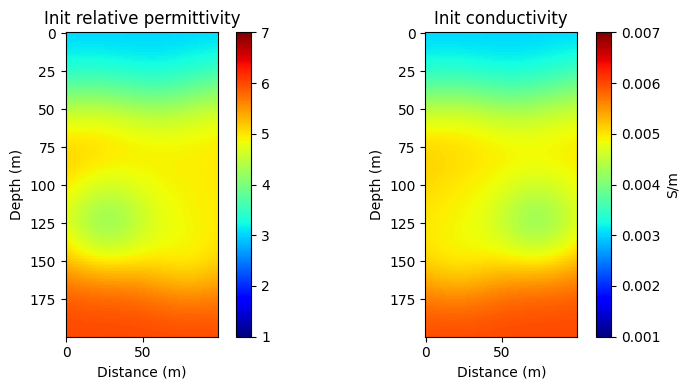

In [2]:
er=torch.tensor(filters.gaussian(ert,sigma=20),device=device)
se=torch.tensor(filters.gaussian(set,sigma=20),device=device)


optimiser_phase1 = torch.optim.Adam([
    {'params': er, 'lr': 0.2},
])

optimiser_phase2 = torch.optim.Adam([
    {'params': er, 'lr': 0.1},
    {'params': se, 'lr': 0.0001}
])
phase1_epochs = 50 
losses = []
n_epochs=201

loss_fnmse = torch.nn.MSELoss()
loss_fnl1= torch.nn.L1Loss()

start_time = time.time()


tv_criterion = DeepGPR.TVRegularization(weight_ep=20,weight_sigma=0.0000000001).to(device)


fig, axes = plt.subplots(1, 2, figsize=(8, 4))  
im1 = axes[0].imshow(er[10:-10,10:-10].cpu().numpy(),
                     cmap='jet',
                     interpolation='nearest',
                     aspect='equal',vmax=7,vmin=1)
cbar1 = plt.colorbar(im1, ax=axes[0])
axes[0].set_title('Init relative permittivity')
axes[0].set_xlabel('Distance (m)')
axes[0].set_ylabel('Depth (m)')

im2 = axes[1].imshow(se[10:-10,10:-10].cpu().numpy(),
                     cmap='jet',
                     interpolation='nearest',
                     aspect='equal',vmax=0.007,vmin=0.001)
cbar2 = plt.colorbar(im2, ax=axes[1])
cbar2.set_label('S/m')
axes[1].set_title('Init conductivity')
axes[1].set_xlabel('Distance (m)')
axes[1].set_ylabel('Depth (m)')

plt.tight_layout()
plt.show()


Epoch 0, Total Loss: 1612276.35 (Data: 1601686.62), Epoch Time: 1.82s, Total Time: 2.11s


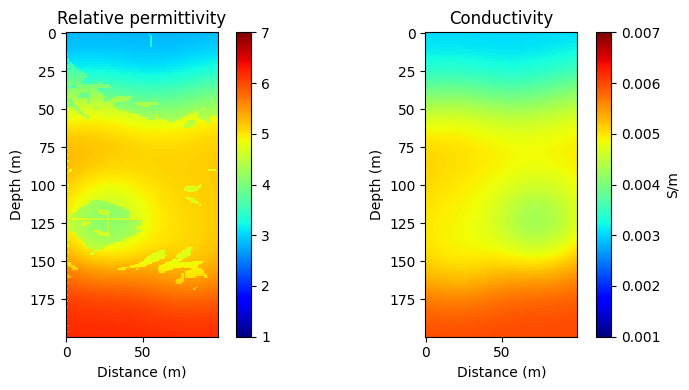

Epoch 1, Total Loss: 1301439.76 (Data: 1275185.50), Epoch Time: 1.53s, Total Time: 4.00s
Epoch 2, Total Loss: 1223791.57 (Data: 1186539.38), Epoch Time: 1.55s, Total Time: 5.55s
Epoch 3, Total Loss: 1166691.33 (Data: 1120120.50), Epoch Time: 1.54s, Total Time: 7.09s
Epoch 4, Total Loss: 1116633.33 (Data: 1062277.62), Epoch Time: 1.56s, Total Time: 8.64s
Epoch 5, Total Loss: 995662.96 (Data: 934430.75), Epoch Time: 1.53s, Total Time: 10.17s
Epoch 6, Total Loss: 940812.79 (Data: 873943.25), Epoch Time: 1.56s, Total Time: 11.73s
Epoch 7, Total Loss: 887543.95 (Data: 817030.12), Epoch Time: 1.54s, Total Time: 13.27s
Epoch 8, Total Loss: 836919.89 (Data: 762842.12), Epoch Time: 1.57s, Total Time: 14.84s
Epoch 9, Total Loss: 785061.08 (Data: 707541.62), Epoch Time: 1.55s, Total Time: 16.39s
Epoch 10, Total Loss: 698794.55 (Data: 618129.38), Epoch Time: 1.55s, Total Time: 17.94s
Epoch 11, Total Loss: 685173.36 (Data: 600891.75), Epoch Time: 1.56s, Total Time: 19.49s
Epoch 12, Total Loss: 6814

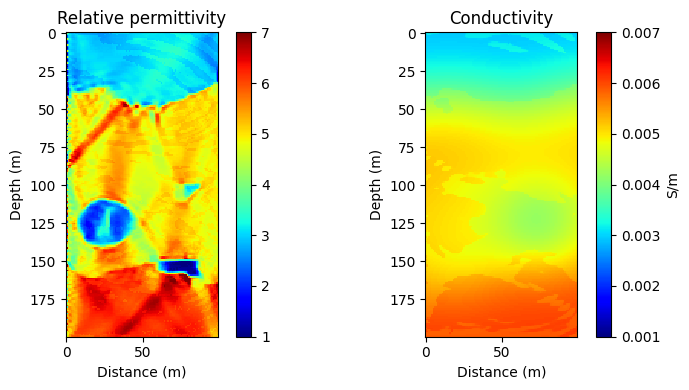

Epoch 51, Total Loss: 488641.84 (Data: 379786.00), Epoch Time: 1.76s, Total Time: 82.25s
Epoch 52, Total Loss: 438501.09 (Data: 331936.69), Epoch Time: 1.55s, Total Time: 83.80s
Epoch 53, Total Loss: 413674.94 (Data: 310605.19), Epoch Time: 1.55s, Total Time: 85.35s
Epoch 54, Total Loss: 369523.02 (Data: 269275.06), Epoch Time: 1.55s, Total Time: 86.90s
Epoch 55, Total Loss: 298408.08 (Data: 201530.12), Epoch Time: 1.56s, Total Time: 88.46s
Epoch 56, Total Loss: 335349.18 (Data: 240458.22), Epoch Time: 1.56s, Total Time: 90.01s
Epoch 57, Total Loss: 294836.01 (Data: 203098.22), Epoch Time: 1.56s, Total Time: 91.57s
Epoch 58, Total Loss: 265329.56 (Data: 175620.56), Epoch Time: 1.55s, Total Time: 93.12s
Epoch 59, Total Loss: 268093.99 (Data: 179968.50), Epoch Time: 1.56s, Total Time: 94.68s
Epoch 60, Total Loss: 264411.86 (Data: 177582.00), Epoch Time: 1.56s, Total Time: 96.24s
Epoch 61, Total Loss: 229238.71 (Data: 143834.25), Epoch Time: 1.58s, Total Time: 97.81s
Epoch 62, Total Loss:

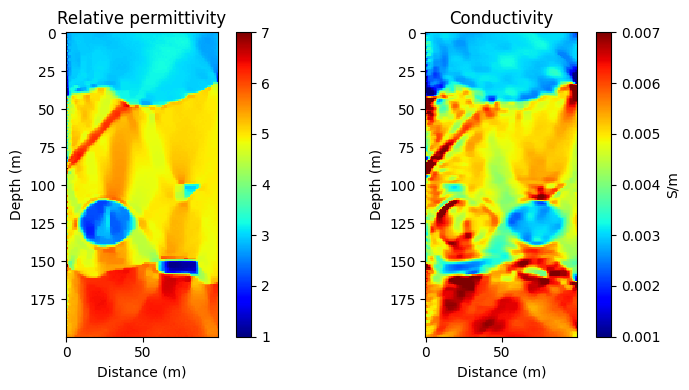

Epoch 101, Total Loss: 137964.62 (Data: 80251.27), Epoch Time: 1.55s, Total Time: 160.00s
Epoch 102, Total Loss: 114419.66 (Data: 56988.74), Epoch Time: 1.54s, Total Time: 161.55s
Epoch 103, Total Loss: 136433.67 (Data: 78756.78), Epoch Time: 1.56s, Total Time: 163.11s
Epoch 104, Total Loss: 127027.84 (Data: 70259.08), Epoch Time: 1.55s, Total Time: 164.66s
Epoch 105, Total Loss: 118581.68 (Data: 62281.37), Epoch Time: 1.56s, Total Time: 166.22s
Epoch 106, Total Loss: 150359.83 (Data: 94439.61), Epoch Time: 1.55s, Total Time: 167.77s
Epoch 107, Total Loss: 133508.62 (Data: 78130.95), Epoch Time: 1.56s, Total Time: 169.33s
Epoch 108, Total Loss: 134556.88 (Data: 79287.99), Epoch Time: 1.56s, Total Time: 170.89s
Epoch 109, Total Loss: 138972.72 (Data: 84202.95), Epoch Time: 1.57s, Total Time: 172.46s
Epoch 110, Total Loss: 121586.04 (Data: 67184.78), Epoch Time: 1.56s, Total Time: 174.01s
Epoch 111, Total Loss: 137409.20 (Data: 83529.23), Epoch Time: 1.56s, Total Time: 175.57s
Epoch 112,

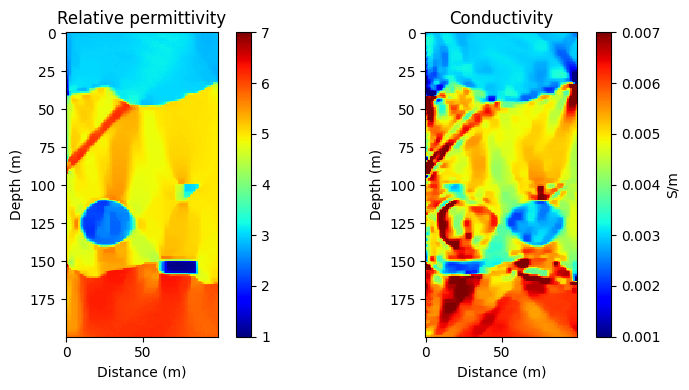

Epoch 151, Total Loss: 112123.57 (Data: 67466.62), Epoch Time: 1.54s, Total Time: 237.94s
Epoch 152, Total Loss: 134193.41 (Data: 89531.59), Epoch Time: 1.57s, Total Time: 239.51s
Epoch 153, Total Loss: 120299.62 (Data: 75898.80), Epoch Time: 1.56s, Total Time: 241.07s
Epoch 154, Total Loss: 132833.18 (Data: 88548.77), Epoch Time: 1.57s, Total Time: 242.64s
Epoch 155, Total Loss: 128425.61 (Data: 84277.08), Epoch Time: 1.59s, Total Time: 244.23s
Epoch 156, Total Loss: 116862.09 (Data: 72762.02), Epoch Time: 1.57s, Total Time: 245.80s
Epoch 157, Total Loss: 112349.47 (Data: 68396.70), Epoch Time: 1.58s, Total Time: 247.38s
Epoch 158, Total Loss: 126463.02 (Data: 82664.72), Epoch Time: 1.56s, Total Time: 248.93s
Epoch 159, Total Loss: 115188.23 (Data: 71598.64), Epoch Time: 1.56s, Total Time: 250.49s
Epoch 160, Total Loss: 128260.50 (Data: 84634.30), Epoch Time: 1.55s, Total Time: 252.05s
Epoch 161, Total Loss: 119569.75 (Data: 76109.36), Epoch Time: 1.54s, Total Time: 253.58s
Epoch 162,

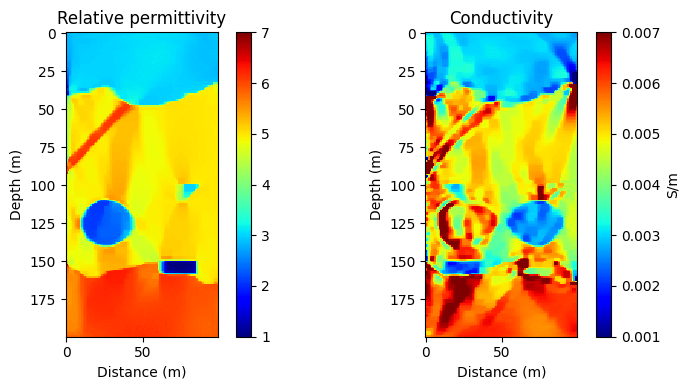

In [3]:

tv_ratio = 0.1 

for epoch in range(n_epochs):
    if epoch < phase1_epochs:
        current_optimizer = optimiser_phase1
        se.requires_grad = False 
        er.requires_grad = True  
    else:
        current_optimizer = optimiser_phase2
        se.requires_grad = True    
        er.requires_grad = True   
    
    epoch_start = time.time()
    
    current_optimizer.zero_grad()

    r = DeepGPR.compute(
        device=device, dx=dx, dt=dt, 
        source_amplitudes=source_amplitudes,
        source_location=source_location, 
        receiver_location=receiver_location, 
        er=er, se=se
    )
  
    loss_data = loss_fnl1(r[-1], r_obs[-1]) * 1e7
    loss_data.backward()

    if er.requires_grad:
        er.grad[:, :10] = 0
        er.grad[:, -10:] = 0
        grad_data_er = er.grad.clone() 
        norm_data_er = torch.norm(grad_data_er) + 1e-8 
        
    if se.requires_grad:
        se.grad[:, :10] = 0
        se.grad[:, -10:] = 0
        grad_data_se = se.grad.clone() 
        norm_data_se = torch.norm(grad_data_se) + 1e-8

    current_optimizer.zero_grad()  
    
    loss_tv = tv_criterion(er, se)
    loss_tv.backward()  

    if er.requires_grad:
        er.grad[:, :10] = 0
        er.grad[:, -10:] = 0
        norm_tv_er = torch.norm(er.grad) + 1e-8
        weight_tv_er = (norm_data_er / norm_tv_er) * tv_ratio
        er.grad = grad_data_er + er.grad * weight_tv_er

    if se.requires_grad:
        se.grad[:, :10] = 0
        se.grad[:, -10:] = 0
        norm_tv_se = torch.norm(se.grad) + 1e-8
        weight_tv_se = (norm_data_se / norm_tv_se) * tv_ratio
        se.grad = grad_data_se + se.grad * weight_tv_se

    current_optimizer.step()
    total_loss = loss_data.item() + loss_tv.item()
    losses.append(total_loss) 
    
    epoch_time = time.time() - epoch_start  
    total_time = time.time() - start_time  
    
    with torch.no_grad():
        se.data.clamp_(min=0)
        er.data.clamp_(min=1)
        
    print(f"Epoch {epoch}, Total Loss: {total_loss:.2f} (Data: {loss_data.item():.2f}), Epoch Time: {epoch_time:.2f}s, Total Time: {total_time:.2f}s")
    
    if epoch % 50 == 0:
        fig, axes = plt.subplots(1, 2, figsize=(8, 4))  
        im1 = axes[0].imshow(er[10:-10,10:-10].detach().cpu().numpy(),
                            cmap='jet',
                            interpolation='nearest',
                            aspect='equal',vmax=7,vmin=1)
        cbar1 = plt.colorbar(im1, ax=axes[0])
        axes[0].set_title('Relative permittivity')
        axes[0].set_xlabel('Distance (m)')
        axes[0].set_ylabel('Depth (m)')

        im2 = axes[1].imshow(se[10:-10,10:-10].detach().cpu().numpy(),
                            cmap='jet',
                            interpolation='nearest',
                            aspect='equal',vmax=0.007,vmin=0.001)
        cbar2 = plt.colorbar(im2, ax=axes[1])
        cbar2.set_label('S/m')
        axes[1].set_title('Conductivity')
        axes[1].set_xlabel('Distance (m)')
        axes[1].set_ylabel('Depth (m)')

        plt.tight_layout()
        plt.show()